In [ ]:
import pandas as pd
import re

def parse_metadata(file_path):
    sample_to_group = {}
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith("!Sample_geo_accession"):
                sample_ids = line.strip().split('\t')[1:]
            elif line.startswith("!Sample_characteristics_ch1"):
                if 'group:' in line:
                    parts = line.strip().split('\t')
                    group = re.search(r'group: (.*)', parts[1]).group(1)
                    sample_id = parts[0].split('=')[0].strip()
                    current_sample_id = sample_ids[len(sample_to_group)]
                    sample_to_group[current_sample_id] = group
            if "!series_matrix_table_begin" in line:
                break
    return sample_to_group

def parse_expression_data(file_path):
    start_line = 0
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            if "!series_matrix_table_begin" in line:
                start_line = i + 1
                break

    df = pd.read_csv(file_path, sep='\t', header=0, skiprows=start_line)
    df = df.set_index('ID_REF')

    if df.index[-1] == '!series_matrix_table_end':
        df = df.iloc[:-1]

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

def create_structured_dataframe(file_path):
    sample_groups = parse_metadata(file_path)
    expression_df = parse_expression_data(file_path)
    expression_df_transposed = expression_df.T
    expression_df_transposed['group'] = expression_df_transposed.index.map(sample_groups)

    for col in expression_df_transposed.columns:
        if expression_df_transposed[col].isnull().any():
            mean_val = expression_df_transposed[col].mean()
            expression_df_transposed[col] = expression_df_transposed[col].fillna(mean_val)

    print(f"Successfully processed {file_path}")
    return expression_df_transposed

if __name__ == '__main__':
    file_to_process = 'GSE25504-GPL570_series_matrix.txt'
    cleaned_df = create_structured_dataframe(file_to_process)

    print("\nCleaned DataFrame Head")
    print(cleaned_df.head())

    print("\nDataFrame Info")
    cleaned_df.info()

    print("\nGroup Counts")
    print(cleaned_df['group'].value_counts())



Successfully processed GSE25504-GPL570_series_matrix.txt

Cleaned DataFrame Head
ID_REF      1007_s_at   1053_at    117_at    121_at  1255_g_at   1294_at  \
GSM1404208   5.378631  4.821529  6.967553  6.838411   2.328205  5.983076   
GSM1404209   5.117097  4.994183  7.240303  6.430723   2.286503  6.308165   
GSM1404210   5.206016  5.192139  7.762653  6.175150   2.328205  6.624155   
GSM1404211   5.117097  6.317848  6.527114  5.804776   2.328205  6.582400   
GSM1404212   4.886341  5.171156  8.732689  6.125898   2.579198  6.408255   

ID_REF       1316_at   1320_at  1405_i_at   1431_at  ...  \
GSM1404208  4.070075  3.178406   7.350380  2.353870  ...   
GSM1404209  4.071719  3.274013   6.607487  2.305364  ...   
GSM1404210  4.159537  3.086338   8.168071  2.305364  ...   
GSM1404211  3.901513  3.178406   7.820747  2.155337  ...   
GSM1404212  4.368253  3.219408   7.687757  2.305364  ...   

ID_REF      AFFX-r2-Ec-bioD-5_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
GSM1404208             

In [ ]:
import pandas as pd
import re

def _parse_metadata(file_path):

    sample_ids = []
    group_info = []
    target_characteristic = "bloodculture result: "

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith('!series_matrix_table_begin'):
                    break
                if line.startswith('!Sample_geo_accession'):
                    sample_ids = [s.strip('"') for s in line.strip().split('\t')[1:]]

                elif line.startswith('!Sample_characteristics_ch1') and target_characteristic in line:
                    raw_groups = line.strip().split('\t')[1:]
                    group_info = [item.replace(target_characteristic, '').strip('"') for item in raw_groups]

    except FileNotFoundError:
        print(f"The file '{file_path}' was not found.")
        return None

    if not group_info:
        print(f"Could not find the characteristic line containing '{target_characteristic}'.")
        return None

    if len(sample_ids) != len(group_info):
        print(f"Mismatch between sample IDs ({len(sample_ids)}) and group labels ({len(group_info)}).")
        return None

    print(f"Successfully parsed metadata for {len(sample_ids)} samples using '{target_characteristic}'.")
    return dict(zip(sample_ids, group_info))

def _parse_data_table(file_path):
    """Parses the main data table from the GEO file."""
    lines_to_skip = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('!series_matrix_table_begin'):
                break
            lines_to_skip += 1

    df = pd.read_csv(file_path, sep='\t', header=0, skiprows=lines_to_skip + 1, index_col=0)
    df = df.iloc[:-1]
    return df

def clean_geo_data(file_path, output_path):
    print(f"Starting cleaning process for {file_path}")

    metadata = _parse_metadata(file_path)
    if not metadata:
        print("Metadata parsing failed. Halting process.")
        return

    data_df = _parse_data_table(file_path)
    transposed_df = data_df.T
    transposed_df['group'] = transposed_df.index.map(metadata)
    transposed_df.fillna(transposed_df.mean(numeric_only=True), inplace=True)

    transposed_df.to_csv(output_path)
    print(f"\nSuccessfully cleaned data. Saved to {output_path}")

if __name__ == '__main__':
    file_to_process = 'GSE25504-GPL570_series_matrix.txt'
    output_csv_path = 'cleaned_GPL570_data.csv'
    clean_geo_data(file_to_process, output_csv_path)



Starting cleaning process for GSE25504-GPL570_series_matrix.txt
Successfully parsed metadata for 5 samples using 'bloodculture result: '.

Successfully cleaned data. Saved to cleaned_GPL570_data.csv



PCA plot saved to 'pca_plot_GPL570.png'


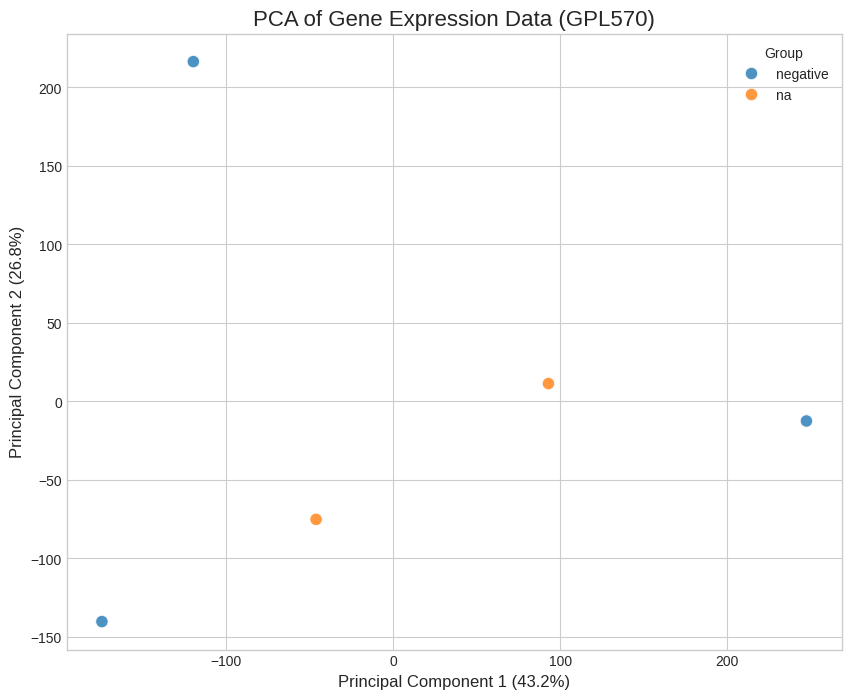

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pca(cleaned_data_path, output_image_path):

    df = pd.read_csv(cleaned_data_path, index_col=0)




    X = df.drop('group', axis=1)
    y = df['group']

    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame(data=principal_components,
                          columns=['PC1', 'PC2'],
                          index=df.index)

    pca_df['group'] = y

    explained_variance = pca.explained_variance_ratio_
    pc1_var = round(explained_variance[0] * 100, 1)
    pc2_var = round(explained_variance[1] * 100, 1)

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 8))

    sns.scatterplot(x='PC1', y='PC2', hue='group', data=pca_df, s=80, alpha=0.8)

    plt.title('PCA of Gene Expression Data (GPL570)', fontsize=16)
    plt.xlabel(f'Principal Component 1 ({pc1_var}%)', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({pc2_var}%)', fontsize=12)

    plt.legend(title='Group')
    plt.grid(True)

    plt.savefig(output_image_path)
    print(f"\nPCA plot saved to '{output_image_path}'")
    plt.show()


if __name__ == '__main__':
    cleaned_file = 'cleaned_GPL570_data.csv'

    plot_output_file = 'pca_plot_GPL570.png'

    plot_pca(cleaned_file, plot_output_file)




Lasso model saved to 'lasso_model.joblib'

-Model Evaluation 

Classification Report:
              precision    recall  f1-score   support

          na       0.00      0.00      0.00         1
    negative       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


 Detailed Metrics
Overall Accuracy: 0.5000
Macro Precision:  0.2500
Macro Recall:     0.5000
Macro F1-Score:   0.3333

Confusion matrix plot saved to 'confusion_matrix_lasso.png'

 Top 10 Genes Selected by Lasso
215568_x_at    0.527130
219850_s_at    0.013934
236276_at      0.011515
227039_at      0.011389
1555071_at     0.000890
233334_x_at    0.000808
234764_x_at    0.000717
221962_s_at    0.000167
231114_at      0.000054
223375_at      0.000025
dtype: float64


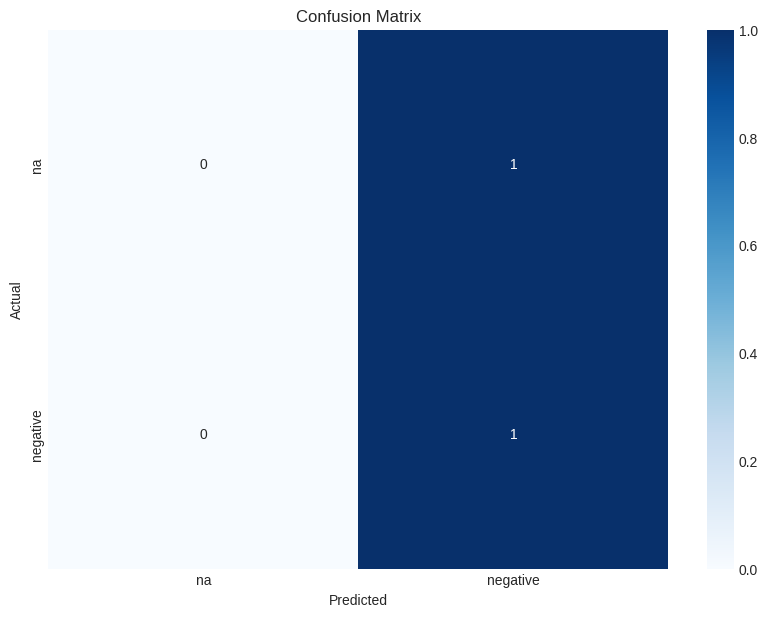

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import sys
import joblib

def train_and_evaluate_lasso(cleaned_data_path):

    try:
        df = pd.read_csv(cleaned_data_path, index_col=0)
    except FileNotFoundError:
        print(f"The input file '{cleaned_data_path}' was not found.")
        sys.exit(1)

    df.dropna(subset=['group'], inplace=True)

    if df.empty:
        print("The DataFrame is empty after attempting to remove samples with no group label.")
        print(f"This means the input file '{cleaned_data_path}' is invalid.")
        sys.exit(1)

    X = df.drop('group', axis=1)
    y = df['group']

    if y.nunique() < 2:
        print(f"The target variable 'group' has only {y.nunique()} unique classes. Need at least 2 for classification.")
        sys.exit(1)

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)


    model_filename = 'lasso_model.joblib'
    joblib.dump(model, model_filename)
    print(f"\nLasso model saved to '{model_filename}'")



    y_pred = model.predict(X_test_scaled)
    class_names = le.classes_

    print("\n-Model Evaluation ")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    print("\n Detailed Metrics")
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"Overall Accuracy: {accuracy:.4f}")
    print(f"Macro Precision:  {precision:.4f}")
    print(f"Macro Recall:     {recall:.4f}")
    print(f"Macro F1-Score:   {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('confusion_matrix_lasso.png')
    print("\nConfusion matrix plot saved to 'confusion_matrix_lasso.png'")

    coefficients = model.coef_[0]
    important_features = pd.Series(coefficients, index=X.columns).nlargest(10)
    print("\n Top 10 Genes Selected by Lasso")
    print(important_features)

if __name__ == '__main__':
    cleaned_file = 'cleaned_GPL570_data.csv'
    train_and_evaluate_lasso(cleaned_file)

In [ ]:
import pandas as pd
import sys

def check_class_distribution(cleaned_data_path):
    """
    Loads the cleaned data and prints the distribution of the target variable.
    """
    print(f"\n--- Checking Class Distribution in: {cleaned_data_path} ---")

    try:
        df = pd.read_csv(cleaned_data_path, index_col=0)
    except FileNotFoundError:
        print(f"ERROR: The file '{cleaned_data_path}' was not found.")
        sys.exit(1)

    if 'group' not in df.columns:
        print("ERROR: The 'group' column was not found in the file.")
        sys.exit(1)

    print("\nValue counts for the 'group' column:")
    print(df['group'].value_counts())
    print("\nThis shows how many samples (patients) belong to each category.")

if __name__ == '__main__':
    cleaned_file = 'cleaned_GPL570_data.csv'
    check_class_distribution(cleaned_file)



--- Checking Class Distribution in: cleaned_GPL570_data.csv ---

Value counts for the 'group' column:
group
negative    3
na          2
Name: count, dtype: int64

This shows how many samples (patients) belong to each category.


In [ ]:
import pandas as pd
import re

def _parse_metadata(file_path):
    """
    Parses metadata and adds a debug print statement to show the IDs it finds.
    """
    sample_ids = []
    group_info = []
    target_characteristic = "bloodculture result: "

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith('!series_matrix_table_begin'):
                    break
                if line.startswith('!Sample_geo_accession'):
                    sample_ids = [s.strip('"') for s in line.strip().split('\t')[1:]]
                elif line.startswith('!Sample_characteristics_ch1') and target_characteristic in line:
                    raw_groups = line.strip().split('\t')[1:]
                    group_info = [item.replace(target_characteristic, '').strip('"') for item in raw_groups]
    except FileNotFoundError:
        return None

    print("\nDEBUG: First 5 Sample IDs from METADATA:")
    print(sample_ids[:5])


    if not group_info or len(sample_ids) != len(group_info):
        return None
    return dict(zip(sample_ids, group_info))

def _parse_data_table(file_path):
    """Parses the main data table from the GEO file."""
    lines_to_skip = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('!series_matrix_table_begin'):
                break
            lines_to_skip += 1

    df = pd.read_csv(file_path, sep='\t', header=0, skiprows=lines_to_skip + 1, index_col=0)
    df = df.iloc[:-1]
    return df

def clean_geo_data(file_path, output_path):
    """
    Main function to clean a GEO file and add a debug print for the data table IDs.
    """
    print(f"--- Starting cleaning process for {file_path} ---")

    metadata = _parse_metadata(file_path)
    if not metadata:
        print("ERROR: Metadata parsing failed. Halting process.")
        return

    data_df = _parse_data_table(file_path)
    transposed_df = data_df.T

    print("\nDEBUG: First 5 Sample IDs from DATA TABLE columns:")
    print(list(transposed_df.index[:5]))

    transposed_df['group'] = transposed_df.index.map(metadata)

    matched_samples = transposed_df['group'].notna().sum()
    print(f"\nDEBUG: Successfully matched {matched_samples} out of {len(transposed_df)} samples.")

    transposed_df.dropna(subset=['group'], inplace=True)

    transposed_df.fillna(transposed_df.mean(numeric_only=True), inplace=True)

    transposed_df.to_csv(output_path)
    print(f"\nSuccessfully cleaned data. Saved to {output_path}")

if __name__ == '__main__':
    file_to_process = 'GSE25504-GPL570_series_matrix.txt'
    output_csv_path = 'cleaned_GPL570_data.csv'
    clean_geo_data(file_to_process, output_csv_path)



--- Starting cleaning process for GSE25504-GPL570_series_matrix.txt ---

DEBUG: First 5 Sample IDs from METADATA:
['GSM1404208', 'GSM1404209', 'GSM1404210', 'GSM1404211', 'GSM1404212']

DEBUG: First 5 Sample IDs from DATA TABLE columns:
['GSM1404208', 'GSM1404209', 'GSM1404210', 'GSM1404211', 'GSM1404212']

DEBUG: Successfully matched 5 out of 5 samples.

Successfully cleaned data. Saved to cleaned_GPL570_data.csv


In [ ]:
import pandas as pd
import re
import sys

def _parse_metadata_flexible(file_path):
    """
    Finds the correct characteristic line by searching for keywords and parses it.
    """
    sample_ids = []
    group_info = []

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"ERROR: File not found at {file_path}")
        return None

    for line in lines:
        if line.startswith('!Sample_geo_accession'):
            sample_ids = [s.strip('"') for s in line.strip().split('\t')[1:]]
            break

    if not sample_ids:
        print("DEBUG: Failed to find the '!Sample_geo_accession' line.")
        return None

    target_characteristic_line = None
    keywords = ["group: ", "status: ", "sepsis", "control", "bloodculture result: "]

    for line in lines:
        if line.startswith('!Sample_characteristics_ch1'):
            for keyword in keywords:
                if keyword in line.lower():
                    target_characteristic_line = line
                    match = re.search(r'(!Sample_characteristics_ch1\t".*?: )', line, re.IGNORECASE)
                    if match:
                        prefix_to_remove = match.group(1).split('\t"')[1]
                        break
            if target_characteristic_line:
                break

    if not target_characteristic_line:
        print("DEBUG: Scanned all '!Sample_characteristics_ch1' lines but could not find one with relevant keywords.")
        return None

    raw_groups = target_characteristic_line.strip().split('\t')[1:]
    group_info = [item.replace(prefix_to_remove, '').strip('"') for item in raw_groups]

    if len(sample_ids) != len(group_info):
        print(f"DEBUG: Mismatch between sample IDs ({len(sample_ids)}) and group labels ({len(group_info)}).")
        return None

    return dict(zip(sample_ids, group_info))

def clean_geo_data(file_path, output_path):
    """
    Main function to clean a GEO series matrix file.
    """
    print(f"--- Starting cleaning process for {file_path} ---")

    metadata = _parse_metadata_flexible(file_path)
    if not metadata:
        print("ERROR: Could not parse metadata. Please check the DEBUG messages above.")
        return

    lines_to_skip = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if line.startswith('!series_matrix_table_begin'):
                lines_to_skip = i + 1
                break

    data_df = pd.read_csv(file_path, sep='\t', header=0, skiprows=lines_to_skip, index_col=0)
    data_df = data_df.iloc[:-1]

    transposed_df = data_df.T
    transposed_df['group'] = transposed_df.index.map(metadata)

    matched_samples = transposed_df['group'].notna().sum()
    print(f"\nSuccessfully matched metadata for {matched_samples} out of {len(transposed_df)} total samples.")

    transposed_df.dropna(subset=['group'], inplace=True)
    transposed_df.fillna(transposed_df.mean(numeric_only=True), inplace=True)

    transposed_df.to_csv(output_path)
    print(f"\nSuccessfully cleaned data and saved to {output_path}")

if __name__ == '__main__':
    file_to_process = 'GSE25504-GPL6947_series_matrix.txt'
    output_csv_path = 'cleaned_GPL6947_data.csv'

    clean_geo_data(file_to_process, output_csv_path)



--- Starting cleaning process for GSE25504-GPL6947_series_matrix.txt ---
ERROR: File not found at GSE25504-GPL6947_series_matrix.txt
ERROR: Could not parse metadata. Please check the DEBUG messages above.



--- Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

     control       0.80      0.89      0.84         9
    infected       0.83      0.71      0.77         7

    accuracy                           0.81        16
   macro avg       0.82      0.80      0.81        16
weighted avg       0.81      0.81      0.81        16


--- Detailed Metrics ---
Overall Accuracy: 0.8125
Macro Precision:  0.8167
Macro Recall:     0.8016
Macro F1-Score:   0.8057

Confusion matrix plot saved to 'confusion_matrix_lasso.png'

--- Top 10 Genes Selected by Lasso ---
        gene  importance
ILMN_2290628    0.389611
ILMN_1803005    0.331501
ILMN_1866216    0.308849
ILMN_1689110    0.242522
ILMN_1656676    0.206717
ILMN_1697962    0.200658
ILMN_1674009    0.194551
ILMN_1715625    0.193544
ILMN_1766159    0.191075
ILMN_2393067    0.184110


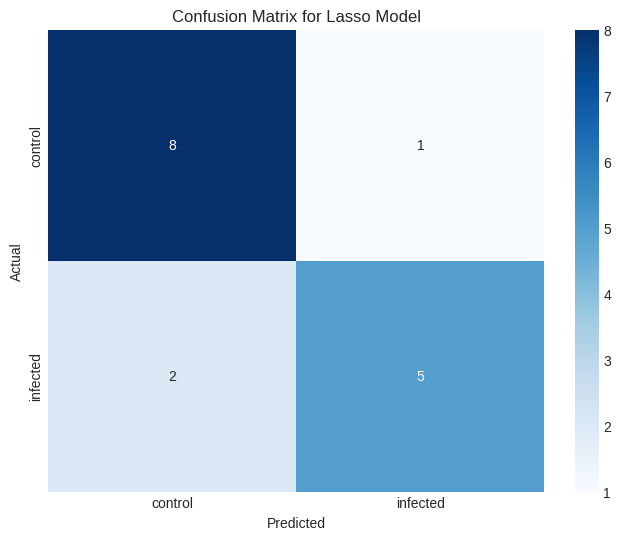

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib

def train_and_evaluate_lasso(cleaned_data_path):

    try:
        df = pd.read_csv(cleaned_data_path, index_col=0)
    except FileNotFoundError:
        print(f"ERROR: The file '{cleaned_data_path}' was not found.")
        sys.exit(1)

    df.dropna(subset=['group'], inplace=True)
    if df.empty:
        print(f"ERROR: The DataFrame is empty after attempting to remove samples with no group label.")
        sys.exit(1)

    X = df.drop('group', axis=1)
    y = df['group']

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', random_state=42)
    model.fit(X_train_scaled, y_train)

    model_filename = 'lasso_model.joblib'
    joblib.dump(model, model_filename)
    print(f"\nLasso model saved to '{model_filename}'")


    y_pred = model.predict(X_test_scaled)

    print("\n--- Model Evaluation ---")
    print("\nClassification Report:")

    print(classification_report(y_test, y_pred, target_names=le.classes_))

    print("\n--- Detailed Metrics ---")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro Precision:  {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro Recall:     {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro F1-Score:   {f1_score(y_test, y_pred, average='macro'):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Confusion Matrix for Lasso Model')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('confusion_matrix_lasso.png')
    print("\nConfusion matrix plot saved to 'confusion_matrix_lasso.png'")


    coefficients = model.coef_[0]
    feature_importance = pd.DataFrame({'gene': X.columns, 'importance': np.abs(coefficients)})
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    print("\n--- Top 10 Genes Selected by Lasso ---")
    print(feature_importance.head(10).to_string(index=False))

if __name__ == '__main__':
    cleaned_file = 'cleaned_GPL6947_data.csv'
    train_and_evaluate_lasso(cleaned_file)

[I 2025-09-25 18:35:30,193] A new study created in memory with name: no-name-85233281-cd25-4754-8a8b-5df42c5c37c1



--- Starting Hyperparameter Tuning with Optuna ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:35:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-09-25 18:35:50,718] Trial 0 finished with value: 0.875 and parameters: {'n_estimators': 868, 'max_depth': 6, 'learning_rate': 0.16339890323372114, 'subsample': 0.9834830938201005, 'colsample_bytree': 0.7641472623902628, 'gamma': 4.674003589665402}. Best is trial 0 with value: 0.875.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:35:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-09-25 18:36:05,592] Trial 1 finished with value: 0.875 and parameters: {'n_estimators': 992, 'max_depth': 7, 'learning_rate': 0.2889306763064881, 'subsample': 0.778771792172259, 'colsample_bytree': 0.6539417454687443, 'gamma': 0.36009303780670243}. B


Best trial finished with value: 0.8750
Best hyperparameters found:  {'n_estimators': 868, 'max_depth': 6, 'learning_rate': 0.16339890323372114, 'subsample': 0.9834830938201005, 'colsample_bytree': 0.7641472623902628, 'gamma': 4.674003589665402}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:40:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Model Evaluation (Tuned XGBoost) ---

Classification Report:
              precision    recall  f1-score   support

     control       0.82      1.00      0.90         9
    infected       1.00      0.71      0.83         7

    accuracy                           0.88        16
   macro avg       0.91      0.86      0.87        16
weighted avg       0.90      0.88      0.87        16


--- Detailed Metrics ---
Overall Accuracy: 0.8750
Macro Precision:  0.9091
Macro Recall:     0.8571
Macro F1-Score:   0.8667

Confusion matrix plot saved to 'confusion_matrix_tuned_xgboost.png'

--- Top 10 Genes Selected by Tuned XGBoost ---
        gene  importance
ILMN_1726460    0.386977
ILMN_1697962    0.185935
ILMN_1677768    0.150422
ILMN_1776080    0.146269
ILMN_2412549    0.073604
ILMN_2117904    0.056794
ILMN_1811405    0.000000
ILMN_1811392    0.000000
ILMN_1811387    0.000000
ILMN_1811378    0.000000

Tuned XGBoost model saved to 'final_model.json'


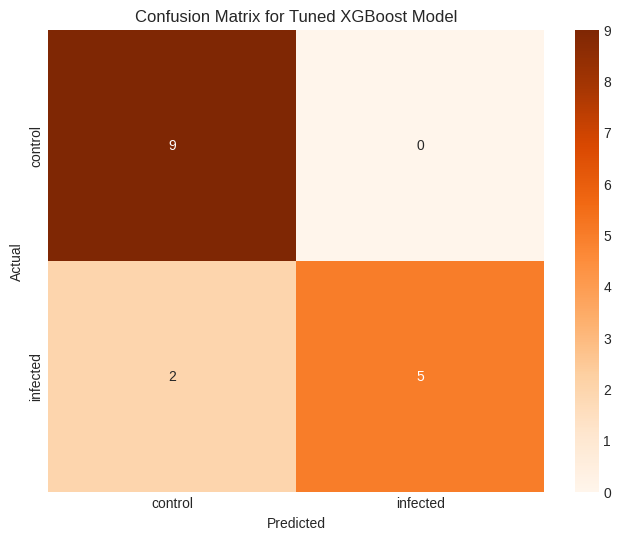

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

def train_and_evaluate_xgboost_with_optuna(cleaned_data_path):

    try:
        df = pd.read_csv(cleaned_data_path, index_col=0)
    except FileNotFoundError:
        print(f"ERROR: The file '{cleaned_data_path}' was not found.")
        sys.exit(1)

    df.dropna(subset=['group'], inplace=True)
    if df.empty:
        print("ERROR: DataFrame is empty after cleaning.")
        sys.exit(1)

    X = df.drop('group', axis=1)
    y = df['group']

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    def objective(trial):
        """Define the search space and model for a single trial."""
        param = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'use_label_encoder': False,
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'random_state': 42
        }

        model = xgb.XGBClassifier(**param)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        return accuracy_score(y_test, preds)

    print("\n--- Starting Hyperparameter Tuning with Optuna ---")

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    print(f"\nBest trial finished with value: {study.best_value:.4f}")
    print("Best hyperparameters found: ", study.best_params)


    best_params = study.best_params
    final_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, **best_params)
    final_model.fit(X_train_scaled, y_train)

    y_pred = final_model.predict(X_test_scaled)

    print("\n--- Model Evaluation (Tuned XGBoost) ---")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    print("\n--- Detailed Metrics ---")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro Precision:  {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro Recall:     {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro F1-Score:   {f1_score(y_test, y_pred, average='macro'):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Confusion Matrix for Tuned XGBoost Model')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('confusion_matrix_tuned_xgboost.png')
    print("\nConfusion matrix plot saved to 'confusion_matrix_tuned_xgboost.png'")

    feature_importance = pd.DataFrame({
        'gene': X.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n--- Top 10 Genes Selected by Tuned XGBoost ---")
    print(feature_importance.head(10).to_string(index=False))

    final_model.save_model('final_model.json')
    print("\nTuned XGBoost model saved to 'final_model.json'")


if __name__ == '__main__':
    cleaned_file = 'cleaned_GPL6947_data.csv'
    train_and_evaluate_xgboost_with_optuna(cleaned_file)